
--- 1. LASSO Regression ---
Model: LASSO Regression
Alpha Hyperparameter: 0.1
Parameter Values (Coefficients): 
[ 2.48496761 -1.49206889 -0.          0.77077978  0.01063494  0.
 -0.          0.24363542 -0.          0.        ]
Mean Squared Error (MSE) on Test Set: 0.2446


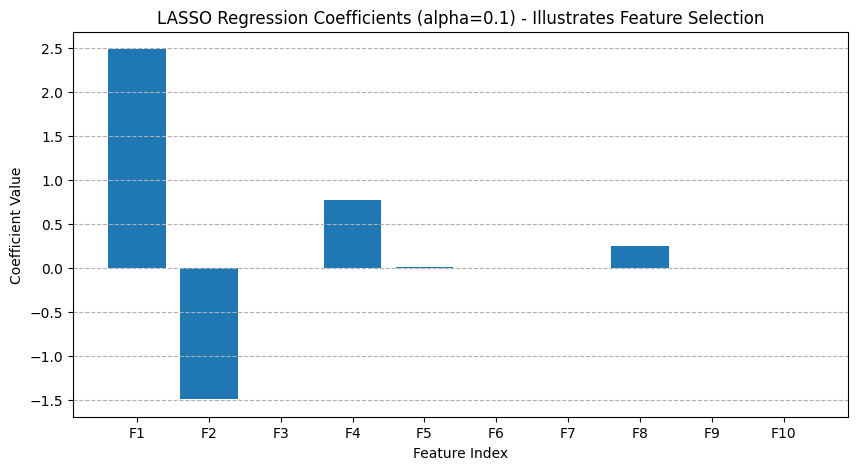


--- 2. K-means Clustering ---
Model: K-means Clustering
K Hyperparameter: 2
Parameter Values (Cluster Centers - Scaled): 
[[ 0.89758627  0.91008317]
 [-0.89758627 -0.91008317]]
Inertia (Within-Cluster Sum of Squares): 36.61


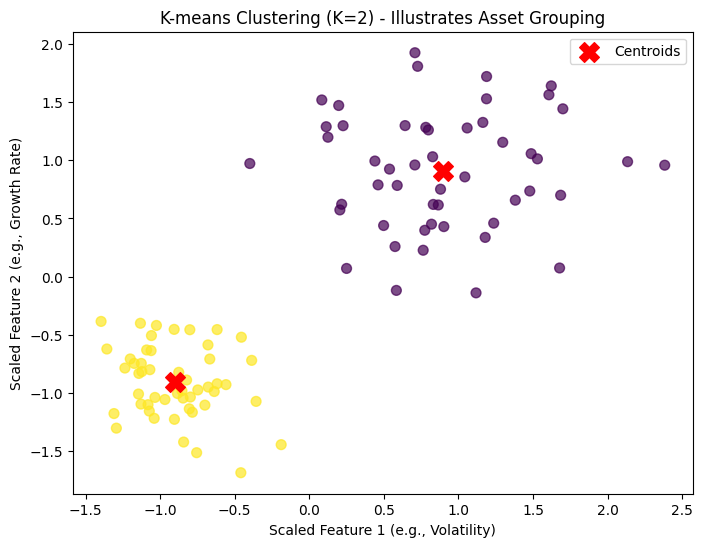


--- 3. Principal Components Analysis (PCA) ---
Model: PCA
n_components Hyperparameter: 3
Explained Variance Ratio by Component: [0.8921706  0.07240716 0.03542224]
Cumulative Explained Variance: [0.8921706  0.96457776 1.        ]


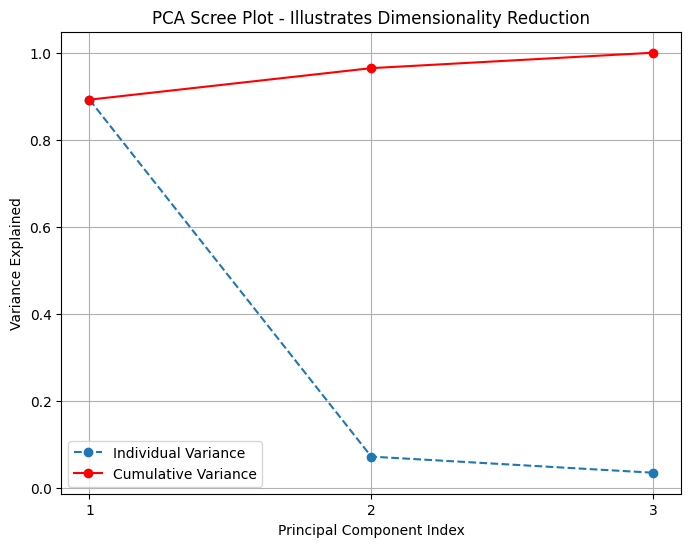


--- 4. Regression Trees ---
Model: Decision Tree Regressor
Max_Depth Hyperparameter: 3
Mean Squared Error (MSE) on Test Set: 0.2234
Feature Importances: [0.96004147 0.03995853 0.        ]


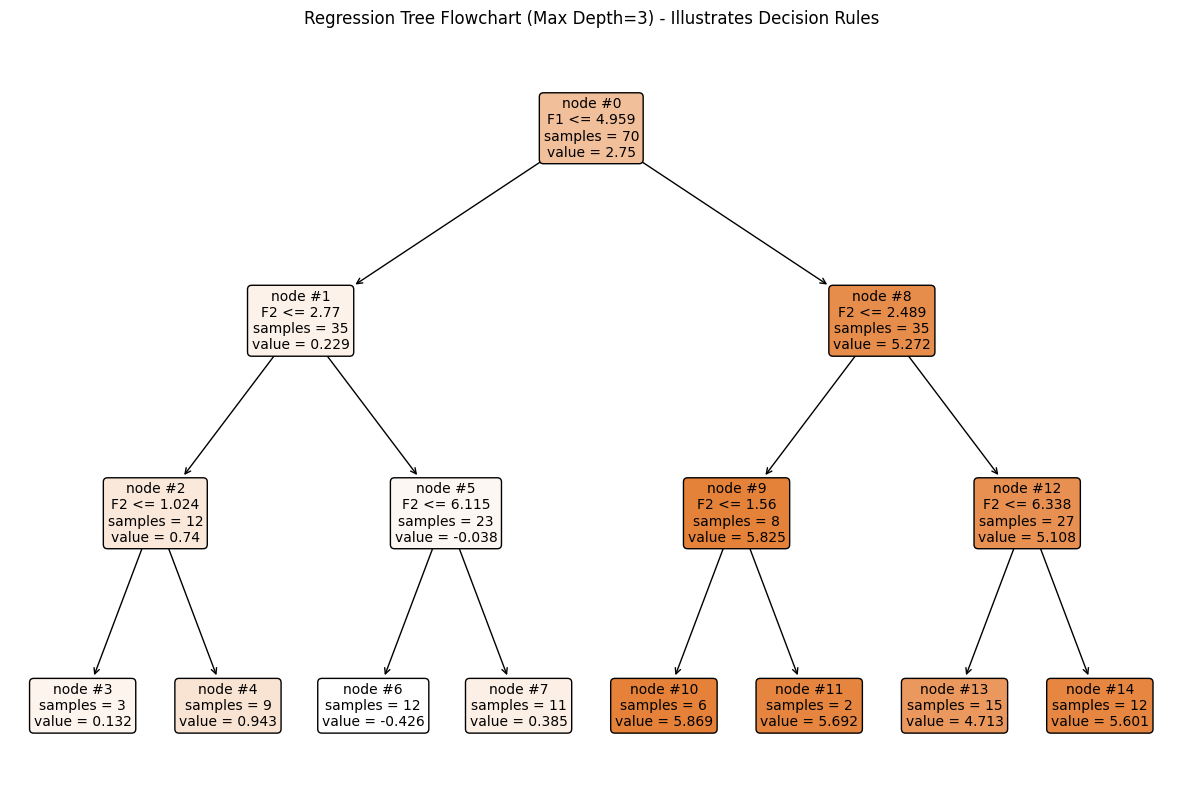

In [7]:
# ====================================================================
# MScFE 632 Group Work Project #1: Computation Section
# Executable Python Notebook - Covering LASSO, K-means, PCA, and Regression Trees
# ====================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from io import StringIO


# Set a seed for reproducibility
np.random.seed(42)

# --- 1. Category 1: LASSO Regression Example ---
print("\n--- 1. LASSO Regression ---")
# Data Generation (Simulated Finance Data: 10 factors predicting a return)
n_samples = 100
n_features = 10
X_lasso = np.random.rand(n_samples, n_features) * 10
true_coef = np.array([2.5, -1.5, 0.0, 0.8, 0.0, 0.0, 0.0, 0.3, 0.0, 0.0]) # Sparse true model
y_lasso = X_lasso @ true_coef + np.random.normal(0, 0.5, n_samples)
X_train_lasso, X_test_lasso, y_train_lasso, y_test_lasso = train_test_split(X_lasso, y_lasso, test_size=0.3, random_state=42)

# Model Training
alpha_value = 0.1
lasso_model = Lasso(alpha=alpha_value)
lasso_model.fit(X_train_lasso, y_train_lasso)

# Prediction and Output
y_pred_test_lasso = lasso_model.predict(X_test_lasso)
mse_test_lasso = mean_squared_error(y_test_lasso, y_pred_test_lasso)

print(f"Model: LASSO Regression")
print(f"Alpha Hyperparameter: {alpha_value}")
print(f"Parameter Values (Coefficients): \n{lasso_model.coef_}")
print(f"Mean Squared Error (MSE) on Test Set: {mse_test_lasso:.4f}")

# Illustration: LASSO Coefficient Plot
plt.figure(figsize=(10, 5))
plt.bar(range(n_features), lasso_model.coef_)
plt.xticks(range(n_features), [f'F{i+1}' for i in range(n_features)])
plt.title(f'LASSO Regression Coefficients (alpha={alpha_value}) - Illustrates Feature Selection')
plt.xlabel('Feature Index')
plt.ylabel('Coefficient Value')
plt.grid(axis='y', linestyle='--')
plt.show()

# --- 2. Category 2: K-means Clustering Example ---
print("\n--- 2. K-means Clustering ---")
# Data Generation (Simulated features for 100 assets: Volatility, Growth)
X_kmeans = np.vstack([
    np.random.normal(loc=[-1, -1], scale=0.5, size=(50, 2)), # Low Volatility, Low Growth
    np.random.normal(loc=[2, 2], scale=0.8, size=(50, 2))  # High Volatility, High Growth
])
scaler_kmeans = StandardScaler()
X_scaled_kmeans = scaler_kmeans.fit_transform(X_kmeans)

# Model Training
k_value = 2
kmeans = KMeans(n_clusters=k_value, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_scaled_kmeans)
centers = kmeans.cluster_centers_

# Output
print(f"Model: K-means Clustering")
print(f"K Hyperparameter: {k_value}")
print(f"Parameter Values (Cluster Centers - Scaled): \n{centers}")
print(f"Inertia (Within-Cluster Sum of Squares): {kmeans.inertia_:.2f}")

# Illustration: K-means Scatter Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_scaled_kmeans[:, 0], X_scaled_kmeans[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title(f'K-means Clustering (K={k_value}) - Illustrates Asset Grouping')
plt.xlabel('Scaled Feature 1 (e.g., Volatility)')
plt.ylabel('Scaled Feature 2 (e.g., Growth Rate)')
plt.legend()
plt.show()

# --- 3. Category 3: Principal Components Analysis (PCA) Example ---
print("\n--- 3. Principal Components Analysis (PCA) ---")
# Data Generation (Simulated highly correlated indices)
rng = np.random.default_rng(42)
true_factor = rng.standard_normal(100)
X_pca = pd.DataFrame({
    'Index_A': 3 * true_factor + rng.normal(0, 0.5, 100),
    'Index_B': 2 * true_factor + rng.normal(0, 0.8, 100),
    'Index_C': 0.5 * true_factor + rng.normal(0, 0.2, 100),
})
X_scaled_pca = StandardScaler().fit_transform(X_pca)

# Model Training
n_components_value = 3
pca = PCA(n_components=n_components_value)
pca.fit(X_scaled_pca)

# Output
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"Model: PCA")
print(f"n_components Hyperparameter: {n_components_value}")
print(f"Explained Variance Ratio by Component: {explained_variance_ratio}")
print(f"Cumulative Explained Variance: {cumulative_variance}")

# Illustration: Scree Plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, n_components_value + 1), explained_variance_ratio, marker='o', linestyle='--', label='Individual Variance')
plt.plot(range(1, n_components_value + 1), cumulative_variance, marker='o', linestyle='-', color='red', label='Cumulative Variance')
plt.title('PCA Scree Plot - Illustrates Dimensionality Reduction')
plt.xlabel('Principal Component Index')
plt.ylabel('Variance Explained')
plt.xticks(range(1, n_components_value + 1))
plt.legend()
plt.grid(True)
plt.show()

# --- 4. Category 4: Regression Trees Example ---
print("\n--- 4. Regression Trees ---")
# Data Generation (Simulated features predicting a continuous value like return)
X_reg = np.random.rand(100, 3) * 10
# A non-linear target variable
y_reg = (X_reg[:, 0] > 5) * 5 + np.sin(X_reg[:, 1]) + np.random.normal(0, 0.2, 100)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

# Model Training
max_depth_value = 3
tree_model = DecisionTreeRegressor(max_depth=max_depth_value, random_state=42)
tree_model.fit(X_train_reg, y_train_reg)

# Prediction and Output
y_pred_test_reg = tree_model.predict(X_test_reg)
mse_test_reg = mean_squared_error(y_test_reg, y_pred_test_reg)
feature_importances = tree_model.feature_importances_

print(f"Model: Decision Tree Regressor")
print(f"Max_Depth Hyperparameter: {max_depth_value}")
print(f"Mean Squared Error (MSE) on Test Set: {mse_test_reg:.4f}")
print(f"Feature Importances: {feature_importances}")

# Illustration: Decision Tree Flowchart
plt.figure(figsize=(15, 10))
plot_tree(tree_model, 
          feature_names=[f'F{i+1}' for i in range(3)],
          filled=True, 
          rounded=True,
          fontsize=10,
          impurity=False,
          node_ids=True)
plt.title(f'Regression Tree Flowchart (Max Depth={max_depth_value}) - Illustrates Decision Rules')
plt.show()